# Adding more data and compare measures

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import os
from itertools import product

from tqdm import tqdm

In [15]:
# Moving to parent directory to import from CDFD and other_helpers
current_dir = os.getcwd()
os.chdir("..")
from CDFD import get_circularity, CDFD
from other_helpers import  uniform_multigraph, in_cycle_ratio, trophic_incoherence,finn_cycling_index_sparse
from scipy.sparse import lil_array, csr_array, diags_array, coo_array, identity, csr_matrix, eye
# Moving back to original directory
os.chdir(current_dir)

### migration data

In [25]:
records = []
base_dir = 'data_migration'

for sub in tqdm(os.listdir(base_dir)):
    folder = os.path.join(current_dir,base_dir, sub)
    if not os.path.isdir(folder):
        continue
    if 'edges.txt' not in os.listdir(folder):
        continue

    # --- load edges only; nodes inferred automatically ---
    edges = pd.read_csv(
        os.path.join(folder,'edges.txt'),
        sep='\t', engine='python'
    )
    G = nx.DiGraph()
    for _, row in edges.iterrows():
        u, v = int(row.Src), int(row.Trg)
        G.add_edge(u, v, weight=float(row.LinkCount))

    # --- infer node list (sorted for reproducibility) ---
    nodes = sorted(G.nodes())

    # --- compute measures ---
    incoh    = trophic_incoherence(G)
    incyc    = in_cycle_ratio(G)
    W        = nx.to_numpy_array(G, nodelist=nodes, weight='weight')
    x        = W.sum(axis=0)
    # fci      = finn_cycling_index_sparse(csr_matrix(W), x)
    C1, D1   = CDFD(G, solution_method='min_cost_pulp')
    circ_max = get_circularity(C1, D1)
    C2, D2   = CDFD(G, solution_method='BFF')
    circ_bff = get_circularity(C2, D2)

    records.append({
        'folder':         sub,
        'incoherence':    incoh,
        'in_cycle_ratio': incyc,
        # 'fci':            fci,
        'circ_max':       circ_max,
        'circ_bff':       circ_bff
    })

# build DataFrame and save
df = pd.DataFrame(records)
df.to_csv('migration_analysis.csv', index=False)
df.head()

  0%|                                                                           | 0/55 [00:00<?, ?it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/07082bf07e5a43cf988a41f577dd8945-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/07082bf07e5a43cf988a41f577dd8945-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 1045 COLUMNS
At line 30977 RHS
At line 32018 BOUNDS
At line 41996 ENDATA
Problem MODEL has 1040 rows, 9977 columns and 19954 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 595 (-445) rows, 7162 (-2815) columns and 14324 (-5630) elements
Perturbing problem by 0.001% of 3 - largest nonzero change 6.0811993e-05 ( 0.0056497849%) - largest zero change 4.6850264e-05
0  Obj 530894.38 Primal inf 88408.286 (586)
86  Obj 584957.37 Primal i

  4%|██▍                                                                | 2/55 [00:01<00:30,  1.74it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/a483708f06c647649874b483afcd49a6-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/a483708f06c647649874b483afcd49a6-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 352 COLUMNS
At line 4544 RHS
At line 4892 BOUNDS
At line 6290 ENDATA
Problem MODEL has 347 rows, 1397 columns and 2794 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 136 (-211) rows, 876 (-521) columns and 1752 (-1042) elements
Perturbing problem by 0.001% of 3 - largest nonzero change 5.8176759e-05 ( 0.0056447641%) - largest zero change 0
0  Obj 81693.356 Primal inf 6494.8043 (135)
46  Obj 85417.332 Primal inf 927.60137 (109)
12

  7%|████▊                                                              | 4/55 [00:01<00:20,  2.49it/s]

...

 95%|██████████████████████████████████████████████████████████████▍   | 52/55 [00:49<00:01,  1.81it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/002f2df2f68f400ea50fc09f26fb73ed-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/002f2df2f68f400ea50fc09f26fb73ed-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 3590 COLUMNS
At line 156285 RHS
At line 159871 BOUNDS
At line 210770 ENDATA
Problem MODEL has 3585 rows, 50898 columns and 101796 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 1885 (-1700) rows, 39324 (-11574) columns and 78648 (-23148) elements
Perturbing problem by 0.001% of 3 - largest nonzero change 6.1408612e-05 ( 0.0056499673%) - largest zero change 4.9148156e-05
0  Obj 4029964.6 Primal inf 659995.93 (1872)
112  Obj 437400

100%|██████████████████████████████████████████████████████████████████| 55/55 [01:18<00:00,  1.44s/it]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/b681c15e03ab43f7a1dac113341ab855-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/b681c15e03ab43f7a1dac113341ab855-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 270 COLUMNS
At line 6694 RHS
At line 6960 BOUNDS
At line 9102 ENDATA
Problem MODEL has 265 rows, 2141 columns and 4282 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 182 (-83) rows, 1857 (-284) columns and 3714 (-568) elements
Perturbing problem by 0.001% of 2 - largest nonzero change 5.8300522e-05 ( 0.0055948105%) - largest zero change 0
0  Obj 112142.49 Primal inf 15630.008 (179)
78  Obj 121956.3 Primal inf 1252.2002 (129)
154 

,folder,incoherence,in_cycle_ratio,circ_max,circ_bff
0,missouri,0.160074,0.720048,0.082940,0.074211
1,southdakota,0.265364,0.855481,0.158667,0.146585
2,alaska,0.155614,0.550183,0.079233,0.067318
3,newhampshire,0.048299,0.467825,0.007456,0.007027
4,illinois,0.077096,0.753532,0.048529,0.046651


In [17]:
records_fw = []
base_dir_fw = 'data_foodweb'

for fname in tqdm(os.listdir(base_dir_fw)):
    if not fname.endswith('.txt'):
        continue
    path = os.path.join(base_dir_fw, fname)
    
    # load edges: no header, whitespace‐delim, quotes around names
    edges = pd.read_csv(
        path,
        sep=r'\s+',
        header=None,
        names=['Src','Trg','Weight'],
        engine='python'
    )
    # strip quotes
    edges['Src'] = edges['Src'].str.strip('"')
    edges['Trg'] = edges['Trg'].str.strip('"')

    # build directed graph
    G = nx.DiGraph()
    for u, v, w in zip(edges.Src, edges.Trg, edges.Weight):
        G.add_edge(u, v, weight=float(w))

    # sorted node list for matrix consistency
    nodes = sorted(G.nodes())

    # compute measures
    incoh    = trophic_incoherence(G)
    incyc    = in_cycle_ratio(G)
    W        = nx.to_numpy_array(G, nodelist=nodes, weight='weight')
    x        = W.sum(axis=0)
    fci      = finn_cycling_index_sparse(csr_matrix(W), x)
    C1, D1   = CDFD(G, solution_method='min_cost_pulp')
    circ_max = get_circularity(C1, D1)
    C2, D2   = CDFD(G, solution_method='BFF')
    circ_bff = get_circularity(C2, D2)

    records_fw.append({
        'file':           fname,
        'incoherence':    incoh,
        'in_cycle_ratio': incyc,
        'fci':            fci,
        'circ_max':       circ_max,
        'circ_bff':       circ_bff
    })

# build DataFrame and save
df_fw = pd.DataFrame(records_fw)
df_fw.to_csv('foodweb_analysis.csv', index=False)
df_fw.head()

  5%|███▌                                                               | 5/94 [00:00<00:03, 24.07it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/fc261b5e0287496892107bf1b84536dd-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/fc261b5e0287496892107bf1b84536dd-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 17 COLUMNS
At line 156 RHS
At line 169 BOUNDS
At line 216 ENDATA
Problem MODEL has 12 rows, 46 columns and 92 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 0 (-12) rows, 0 (-46) columns and 0 (-92) elements
Empty problem - 0 rows, 0 columns and 0 elements
Optimal - objective value 601.648
After Postsolve, objective 601.648, infeasibilities - dual 0 (0), primal 0 (0)
Optimal objective 601.648 - 0 iterations time 0.002, Presolve 0

 12%|███████▋                                                          | 11/94 [00:00<00:03, 24.88it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/d9a719649bb3458cb98577af7ef55a93-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/d9a719649bb3458cb98577af7ef55a93-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 43 COLUMNS
At line 1139 RHS
At line 1178 BOUNDS
At line 1544 ENDATA
Problem MODEL has 38 rows, 365 columns and 730 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 24 (-14) rows, 211 (-154) columns and 422 (-308) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 5.5339243e-05 ( 0.0055339243%) - largest zero change 0
0  Obj 518.65028 Primal inf 14.605977 (24)
31  Obj 530.42978 Primal inf 0.15899 (10)
48  Obj 530.47

 19%|████████████▋                                                     | 18/94 [00:00<00:02, 27.87it/s]

...

 95%|██████████████████████████████████████████████████████████████▍   | 89/94 [00:03<00:00, 32.13it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/30a493ca4d1f4368ba661e04ebc5d919-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/30a493ca4d1f4368ba661e04ebc5d919-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 47 COLUMNS
At line 876 RHS
At line 919 BOUNDS
At line 1196 ENDATA
Problem MODEL has 42 rows, 276 columns and 552 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 27 (-15) rows, 142 (-134) columns and 284 (-268) elements
Perturbing problem by 0.001% of 2 - largest nonzero change 5.5837795e-05 ( 0.0055837795%) - largest zero change 0
0  Obj 713.59767 Primal inf 9.5499736 (27)
31  Obj 720.81898 Primal inf 0.252985 (15)
44  Obj 720.898

100%|██████████████████████████████████████████████████████████████████| 94/94 [00:03<00:00, 28.48it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/28a21d8317ac45cea1b978c7838d98b3-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/28a21d8317ac45cea1b978c7838d98b3-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 16 COLUMNS
At line 68 RHS
At line 80 BOUNDS
At line 98 ENDATA
Problem MODEL has 11 rows, 17 columns and 34 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 0 (-11) rows, 0 (-17) columns and 0 (-34) elements
Empty problem - 0 rows, 0 columns and 0 elements
Optimal - objective value 144.484
After Postsolve, objective 144.484, infeasibilities - dual 0 (0), primal 0 (0)
Optimal objective 144.484 - 0 iterations time 0.002, Presolve 0.00

,file,incoherence,in_cycle_ratio,fci,circ_max,circ_bff
0,FW17.txt,0.059568,0.005223,0.000406,0.003062,0.003062
1,FW16.txt,0.019159,0.002948,0.001970,0.002134,0.002134
2,FW14.txt,0.032310,0.001376,0.000055,0.000199,0.000193
3,FW28.txt,0.028553,0.009112,0.003108,0.005816,0.005816
4,FW29.txt,0.001115,0.000000,0.000000,0.000000,0.000000


In [18]:
records_io = []
base_dir_io = 'data_io'

for fname in tqdm(os.listdir(base_dir_io)):
    if not fname.endswith('.csv'):
        continue
    path = os.path.join(base_dir_io, fname)
    
    # load adjacency matrix, dropping the first row/column of names
    df = pd.read_csv(path, index_col=0)
    nodes = list(df.index)
    
    # build directed graph
    G = nx.DiGraph()
    G.add_nodes_from(nodes)
    for src in nodes:
        for trg in nodes:
            w = df.at[src, trg]
            if w and w != 0:
                G.add_edge(src, trg, weight=float(w))
    
    # compute measures
    incoh    = trophic_incoherence(G)
    incyc    = in_cycle_ratio(G)
    W        = nx.to_numpy_array(G, nodelist=nodes, weight='weight')
    x        = W.sum(axis=0)
    fci      = finn_cycling_index_sparse(csr_matrix(W), x)
    C1, D1   = CDFD(G, solution_method='min_cost_pulp')
    circ_max = get_circularity(C1, D1)
    C2, D2   = CDFD(G, solution_method='BFF')
    circ_bff = get_circularity(C2, D2)
    
    records_io.append({
        'file':           fname,
        'incoherence':    incoh,
        'in_cycle_ratio': incyc,
        'fci':            fci,
        'circ_max':       circ_max,
        'circ_bff':       circ_bff
    })

# build DataFrame and save
df_io = pd.DataFrame(records_io)
df_io.to_csv('io_analysis.csv', index=False)
df_io.head()


  0%|▏                                                                 | 2/660 [00:00<01:25,  7.68it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/aadb10b1bc0d4a1b809d69e15512bcd4-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/aadb10b1bc0d4a1b809d69e15512bcd4-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 40 COLUMNS
At line 3608 RHS
At line 3644 BOUNDS
At line 4834 ENDATA
Problem MODEL has 35 rows, 1189 columns and 2378 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 35 (0) rows, 1189 (0) columns and 2378 (0) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 1.049027e-05 ( 0.001049027%) - largest zero change 0
0  Obj 0 Primal inf 59912.6 (35)
31  Obj 36642.986 Primal inf 2207.8 (22)
65  Obj 36762.689 Primal inf 48

  1%|▍                                                                 | 4/660 [00:00<01:03, 10.26it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/16b64fa868114b9cbd79f2e8f22e6f5e-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/16b64fa868114b9cbd79f2e8f22e6f5e-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 40 COLUMNS
At line 2897 RHS
At line 2933 BOUNDS
At line 3886 ENDATA
Problem MODEL has 35 rows, 952 columns and 1904 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 35 (0) rows, 952 (0) columns and 1904 (0) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 1.049027e-05 ( 0.001049027%) - largest zero change 0
0  Obj 0 Primal inf 13070 (35)
33  Obj 7963.1632 Primal inf 1282.2 (25)
65  Obj 8263.6647 Primal inf 13.699

  1%|▊                                                                 | 8/660 [00:00<00:54, 11.91it/s]

...

 99%|███████████████████████████████████████████████████████████████▌| 656/660 [00:52<00:00, 11.72it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/76c8812d52e541f7b0baf89d90a197ee-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/76c8812d52e541f7b0baf89d90a197ee-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 40 COLUMNS
At line 3275 RHS
At line 3311 BOUNDS
At line 4390 ENDATA
Problem MODEL has 35 rows, 1078 columns and 2156 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 35 (0) rows, 1078 (0) columns and 2156 (0) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 1.049027e-05 ( 0.001049027%) - largest zero change 0
0  Obj 0 Primal inf 1126036.4 (35)
37  Obj 770569.65 Primal inf 47856 (21)
68  Obj 774232.2 Primal inf 15

100%|████████████████████████████████████████████████████████████████| 660/660 [00:52<00:00, 12.46it/s]

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Users/yijie/.pyenv/versions/3.11.12/envs/myenv311/lib/python3.11/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/40ade301e62c4385ba13d182a73bd19c-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/8m/tlrl9p6s7371ym2ydbzyxkbw0000gn/T/40ade301e62c4385ba13d182a73bd19c-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 40 COLUMNS
At line 3584 RHS
At line 3620 BOUNDS
At line 4802 ENDATA
Problem MODEL has 35 rows, 1181 columns and 2362 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Presolve 35 (0) rows, 1181 (0) columns and 2362 (0) elements
Perturbing problem by 0.001% of 1 - largest nonzero change 1.049027e-05 ( 0.001049027%) - largest zero change 0
0  Obj 0 Primal inf 93147.2 (35)
37  Obj 56204.125 Primal inf 987.1 (12)
55  Obj 56204.126
Optimal - obje

,file,incoherence,in_cycle_ratio,fci,circ_max,circ_bff
0,2008_NZL.csv,0.743341,1.0,0.013000,0.599726,0.540613
1,2008_PRT.csv,0.791508,1.0,0.001250,0.657235,0.582280
2,2011_CRI.csv,0.651420,1.0,0.006897,0.520467,0.458442
3,2008_ISR.csv,0.576904,1.0,0.006224,0.432790,0.381071
4,2014_LUX.csv,0.772604,1.0,0.000000,0.640808,0.588994


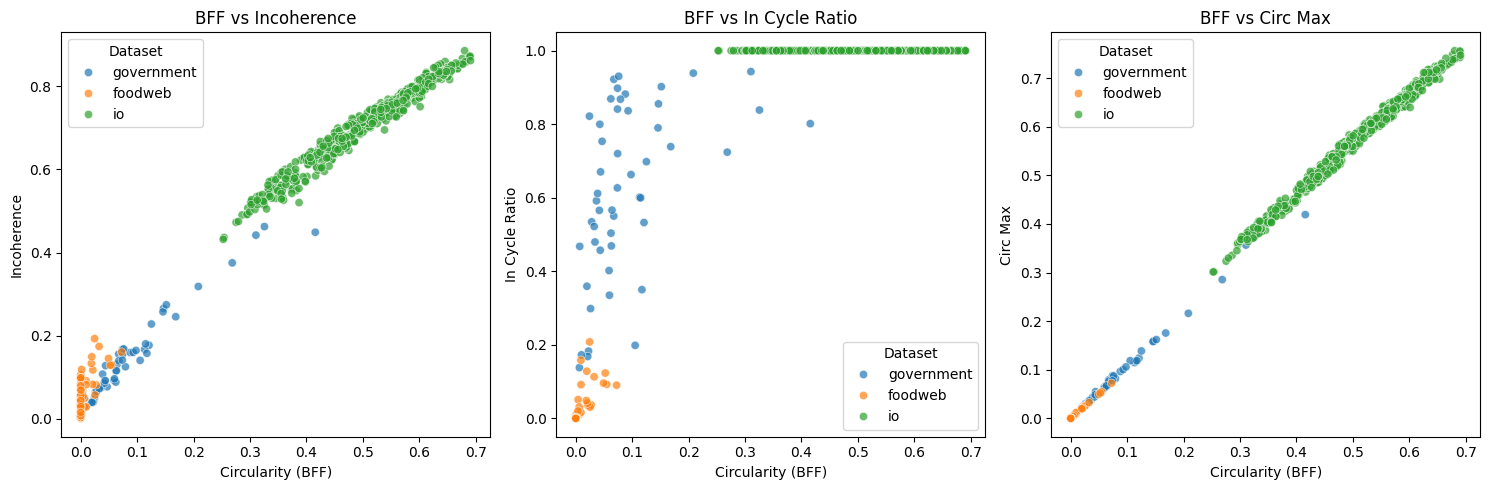

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load data if not already in memory
df    = pd.read_csv('government_analysis.csv')
df_fw = pd.read_csv('foodweb_analysis.csv')
df_io = pd.read_csv('io_analysis.csv')

# Tag each dataset
df['dataset']    = 'government'
df_fw['dataset'] = 'foodweb'
df_io['dataset'] = 'io'

# Combine into one DataFrame
combined = pd.concat([df, df_fw, df_io], ignore_index=True)

measures = ['incoherence', 'in_cycle_ratio', 'circ_max']
palette = {'government':'tab:blue','foodweb':'tab:orange', 'io':'tab:green'}

# Create 2×2 grid of scatter plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for ax, measure in zip(axes, measures):
    sns.scatterplot(
        data=combined,
        x='circ_bff',
        y=measure,
        hue='dataset',
        palette=palette,
        alpha=0.7,
        ax=ax
    )
    ax.set_title(f'BFF vs {measure.replace("_", " ").title()}')
    
    ax.set_xlabel('Circularity (BFF)')
    ax.set_ylabel(measure.replace('_', ' ').title())
    ax.legend(title='Dataset')

plt.tight_layout()
plt.show()
